In [19]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [20]:
df = pd.read_csv("cleaned_superstore.csv")

In [21]:
df

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Quantity,Discount,Profit,Order Year,Order Month,Month Name,Quarter,Day Name,Delivery Days,Profit Margin
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,2,0.00,41.9136,2016,11,November,4,Tuesday,3,16.00
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,3,0.00,219.5820,2016,11,November,4,Tuesday,3,30.00
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,2,0.00,6.8714,2016,6,June,2,Sunday,4,47.00
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,5,0.45,-383.0310,2015,10,October,4,Sunday,7,-40.00
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,2,0.20,2.5164,2015,10,October,4,Sunday,7,11.25
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
9989,9990,CA-2014-110422,2014-01-21,2014-01-23,Second Class,TB-21400,Tom Boeckenhauer,Consumer,United States,Miami,...,3,0.20,4.1028,2014,1,January,1,Tuesday,2,16.25
9990,9991,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,2,0.00,15.6332,2017,2,February,1,Sunday,5,17.00
9991,9992,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,2,0.20,19.3932,2017,2,February,1,Sunday,5,7.50
9992,9993,CA-2017-121258,2017-02-26,2017-03-03,Standard Class,DB-13060,Dave Brooks,Consumer,United States,Costa Mesa,...,4,0.00,13.3200,2017,2,February,1,Sunday,5,45.00


In [22]:
df["Order Date"] = pd.to_datetime(df["Order Date"])

In [23]:
plt.style.use("ggplot")

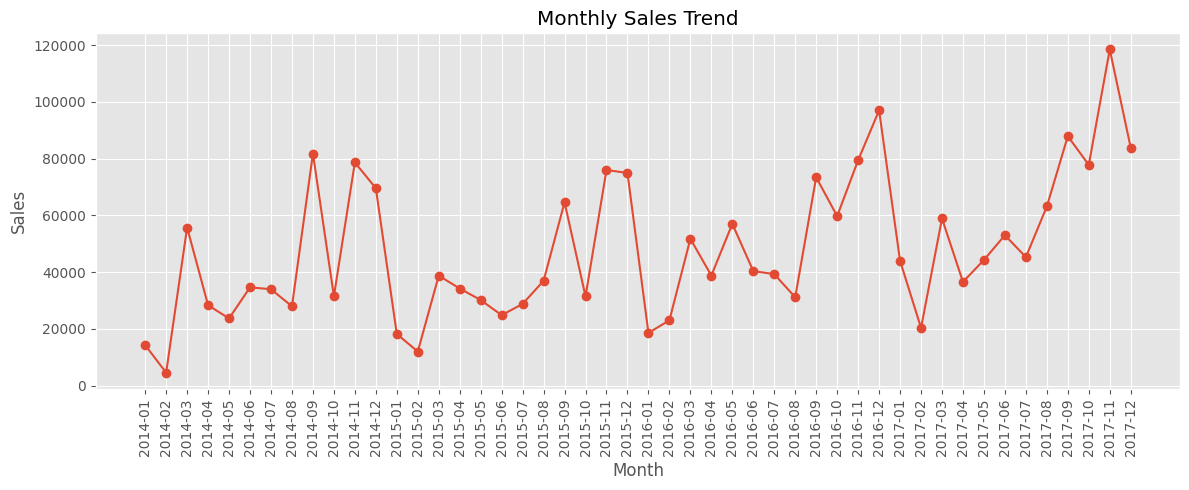

In [24]:
#Monthly Sales Trend - How do sales change over time?

monthly_sales = (df.groupby(df["Order Date"].dt.to_period("M"))["Sales"].sum())

monthly_sales.index = monthly_sales.index.astype(str)

plt.figure(figsize=(12,5))
plt.plot(monthly_sales.index, monthly_sales.values, marker="o")
plt.xticks(rotation=90)
plt.title("Monthly Sales Trend")
plt.xlabel("Month")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()

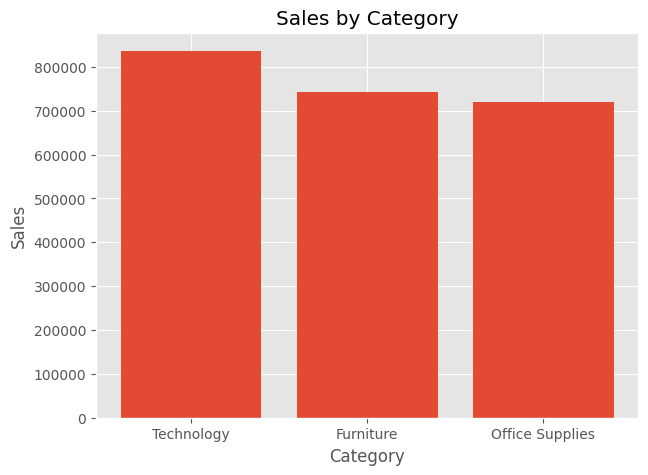

In [25]:
#Sales by Category - Which category generates the highest revenue?

category_sales = (df.groupby("Category")["Sales"].sum().sort_values(ascending=False))

plt.figure(figsize=(7,5))
plt.bar(category_sales.index, category_sales.values)
plt.title("Sales by Category")
plt.xlabel("Category")
plt.ylabel("Sales")
plt.show()

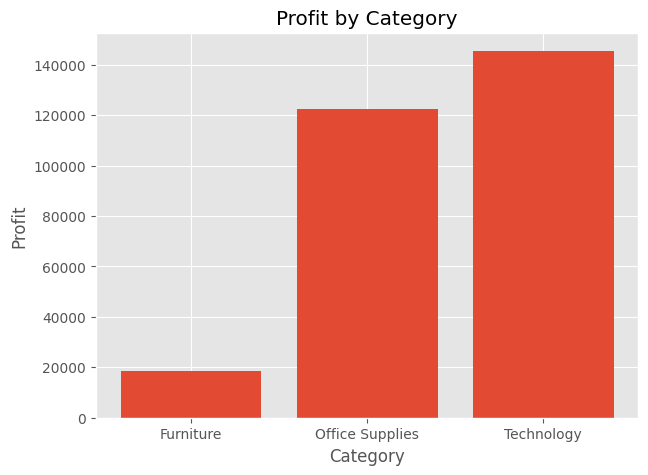

In [26]:
#Profit by Category

category_profit = (df.groupby("Category")["Profit"].sum())

plt.figure(figsize=(7,5))
plt.bar(category_profit.index, category_profit.values)
plt.title("Profit by Category")
plt.xlabel("Category")
plt.ylabel("Profit")
plt.show()

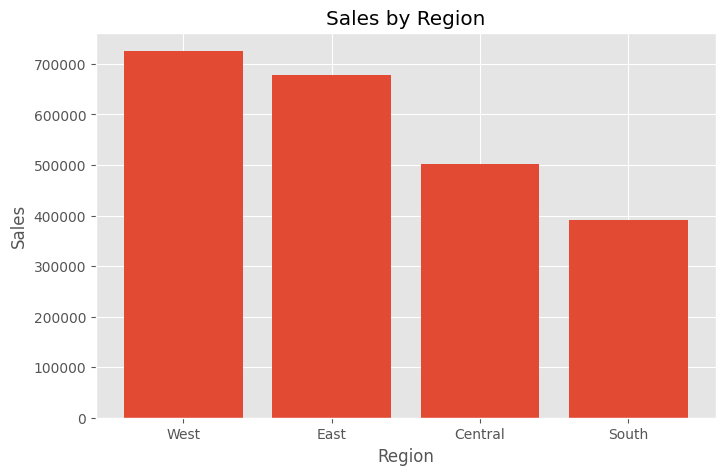

In [27]:
#Sales by Region

region_sales = (df.groupby("Region")["Sales"].sum().sort_values(ascending=False))

plt.figure(figsize=(8,5))
plt.bar(region_sales.index, region_sales.values)
plt.title("Sales by Region")
plt.xlabel("Region")
plt.ylabel("Sales")
plt.show()

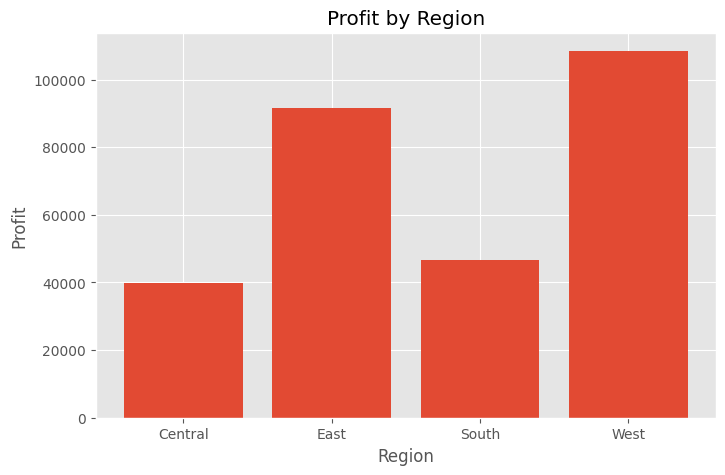

In [28]:
#Profit by Region
region_profit = (df.groupby("Region")["Profit"].sum())

plt.figure(figsize=(8,5))
plt.bar(region_profit.index, region_profit.values)
plt.title("Profit by Region")
plt.xlabel("Region")
plt.ylabel("Profit")
plt.show()

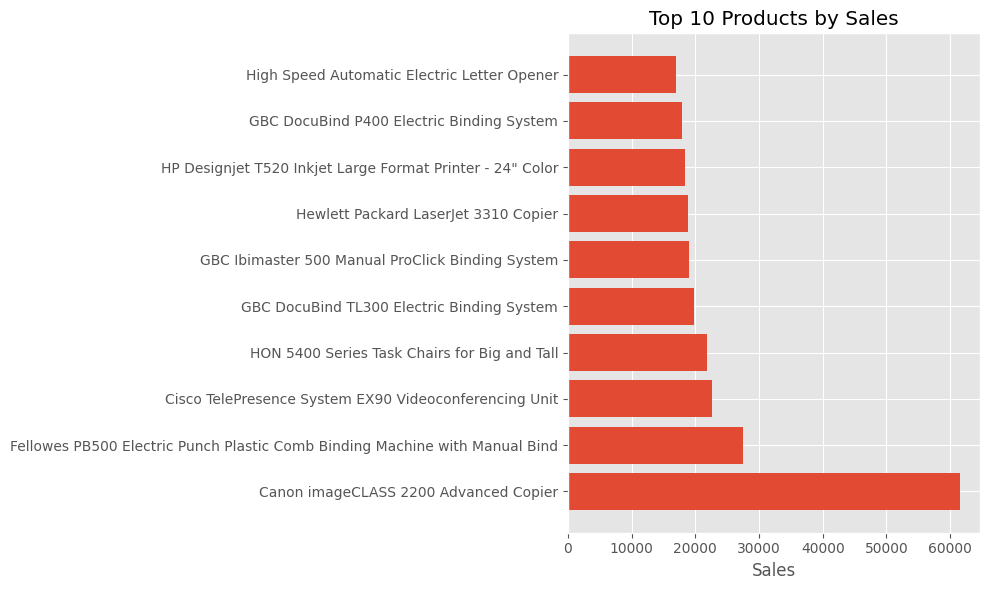

In [29]:
#Top 10 Products
top_products = (df.groupby("Product Name")["Sales"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))
plt.barh(top_products.index, top_products.values)
plt.title("Top 10 Products by Sales")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

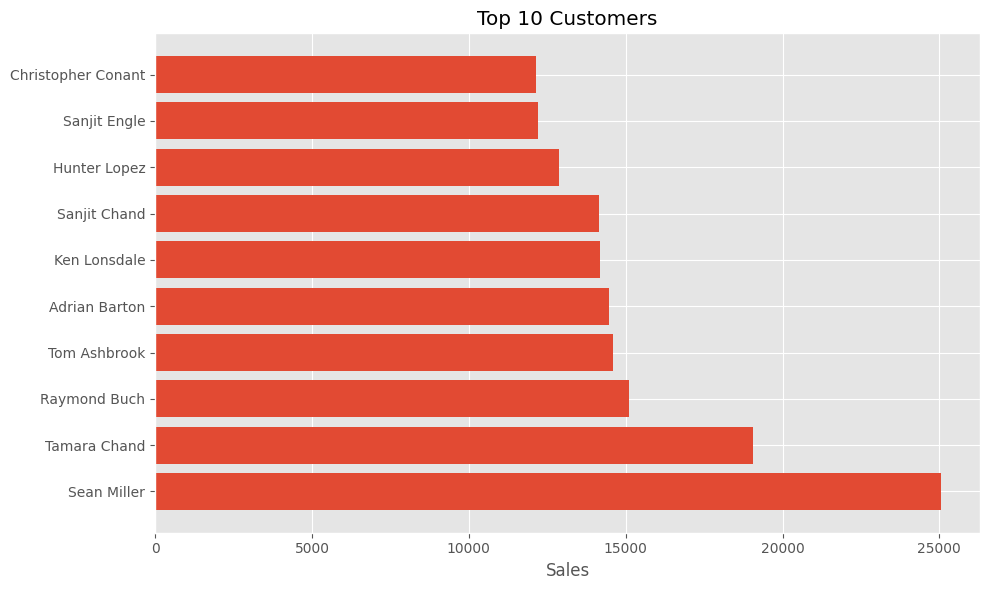

In [30]:
#Top 10 Customers
top_customers = (df.groupby("Customer Name")["Sales"].sum().sort_values(ascending=False).head(10))

plt.figure(figsize=(10,6))
plt.barh(top_customers.index, top_customers.values)
plt.title("Top 10 Customers")
plt.xlabel("Sales")
plt.tight_layout()
plt.show()

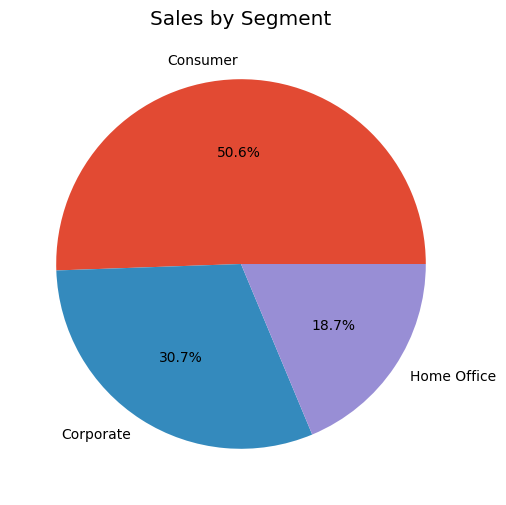

In [31]:
#Sales by Segment
segment_sales = (df.groupby("Segment")["Sales"].sum())

plt.figure(figsize=(6,6))
plt.pie(
    segment_sales,
    labels=segment_sales.index,
    autopct="%1.1f%%"
)
plt.title("Sales by Segment")
plt.show()

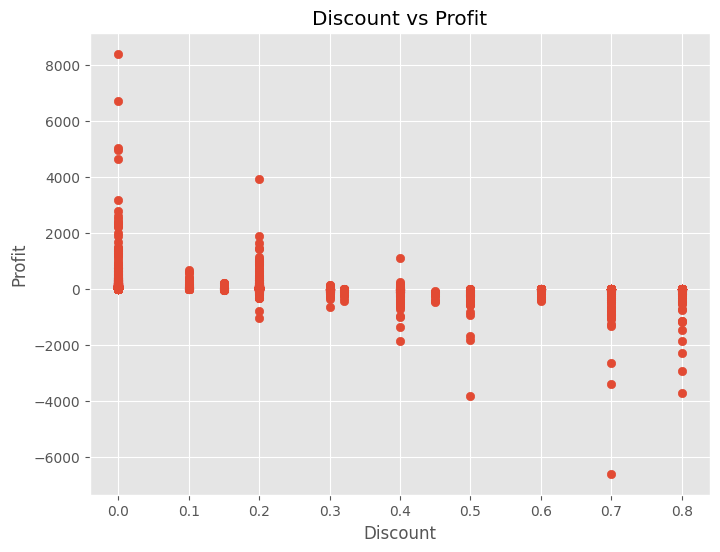

In [32]:
#Discount vs Profit - Do larger discounts reduce profitability?

plt.figure(figsize=(8,6))
plt.scatter(df["Discount"],df["Profit"])
plt.title("Discount vs Profit")
plt.xlabel("Discount")
plt.ylabel("Profit")
plt.show()

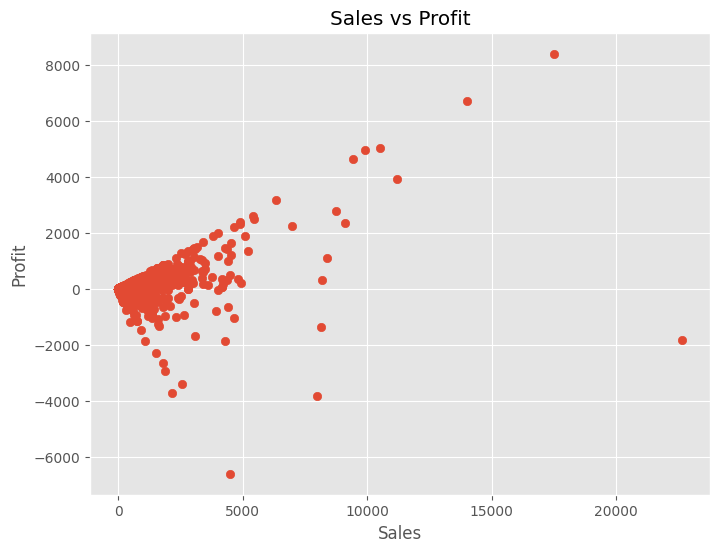

In [33]:
#Sales vs Profit
plt.figure(figsize=(8,6))
plt.scatter(df["Sales"],df["Profit"])
plt.title("Sales vs Profit")
plt.xlabel("Sales")
plt.ylabel("Profit")
plt.show()

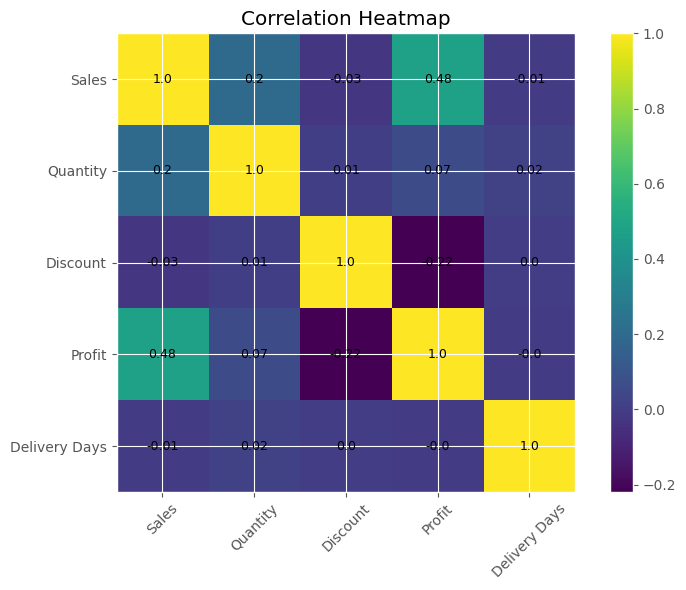

In [34]:
#Correlation Heatmap

import matplotlib.pyplot as plt

corr = df[
    [
        "Sales",
        "Quantity",
        "Discount",
        "Profit",
        "Delivery Days"
    ]
].corr()

plt.figure(figsize=(8,6))
plt.imshow(corr)

plt.colorbar()

plt.xticks(range(len(corr.columns)), corr.columns, rotation=45)
plt.yticks(range(len(corr.columns)), corr.columns)

for i in range(len(corr.columns)):
    for j in range(len(corr.columns)):
        plt.text(
            j,
            i,
            round(corr.iloc[i, j], 2),
            ha="center",
            va="center",
            fontsize=9
        )

plt.title("Correlation Heatmap")
plt.tight_layout()
plt.show()

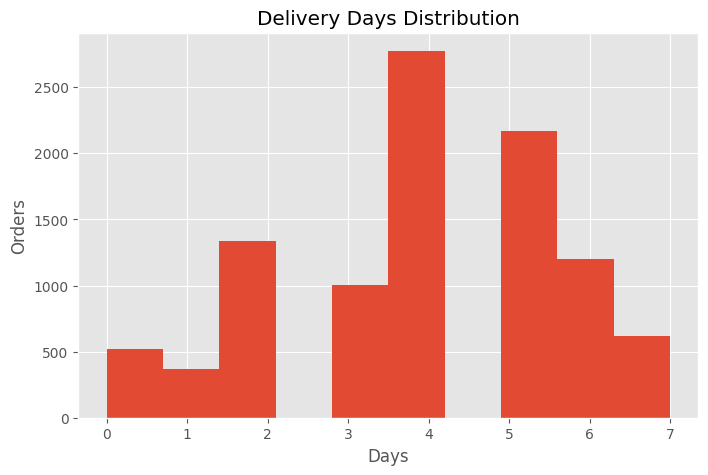

In [35]:
#Delivery Days Distribution

plt.figure(figsize=(8,5))
plt.hist(
    df["Delivery Days"],
    bins=10
)

plt.title("Delivery Days Distribution")
plt.xlabel("Days")
plt.ylabel("Orders")
plt.show()

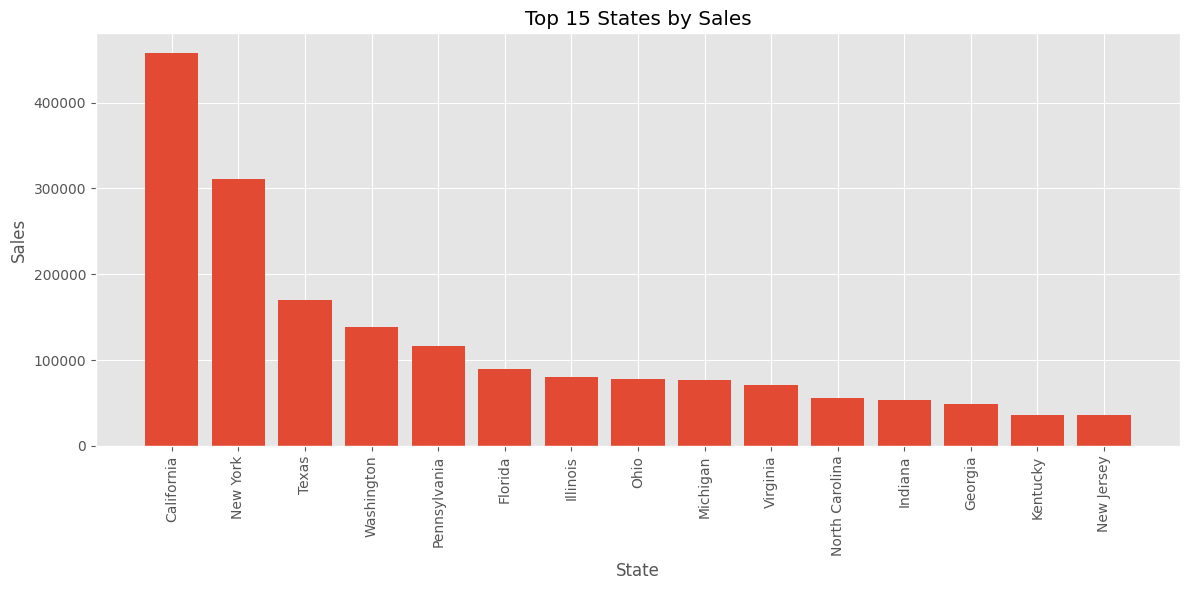

In [36]:
#State-wise Sales
state_sales = (df.groupby("State")["Sales"].sum().sort_values(ascending=False).head(15))

plt.figure(figsize=(12,6))
plt.bar(state_sales.index, state_sales.values)
plt.xticks(rotation=90)
plt.title("Top 15 States by Sales")
plt.xlabel("State")
plt.ylabel("Sales")
plt.tight_layout()
plt.show()